# Kernal PCA

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

In [95]:
x, y = make_circles(n_samples=1000, noise=0.05, factor=0.2, random_state=42)

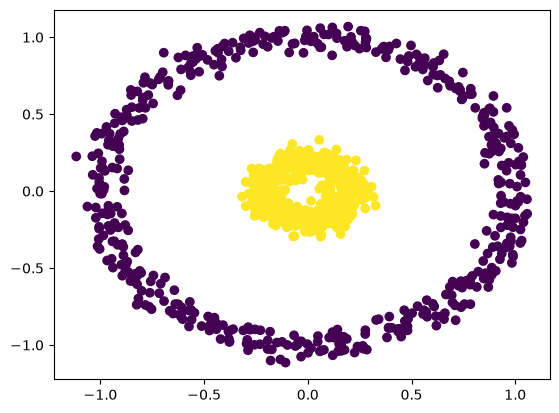

In [96]:
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

In [97]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

## Normal PCA

In [98]:
pca = PCA(n_components=1)

x_train_transform = pca.fit_transform(x_train)
x_test_transform = pca.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train_transform, y_train)
y_pred = knn.predict(x_test_transform)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.79      0.87       100
           1       0.82      0.98      0.89       100

    accuracy                           0.89       200
   macro avg       0.90      0.89      0.88       200
weighted avg       0.90      0.89      0.88       200



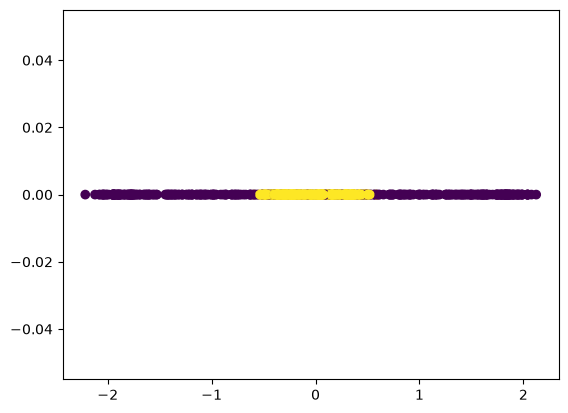

In [99]:
plt.scatter(x_train_transform, np.zeros((x_train_transform.shape[0],)), c=y_train)

plt.show()

## KernalPCA

In [100]:
kpca = KernelPCA(n_components=1, kernel='rbf')

x_train_transform = kpca.fit_transform(x_train)
x_test_transform = kpca.transform(x_test)

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train_transform, y_train)
y_pred = knn.predict(x_test_transform)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



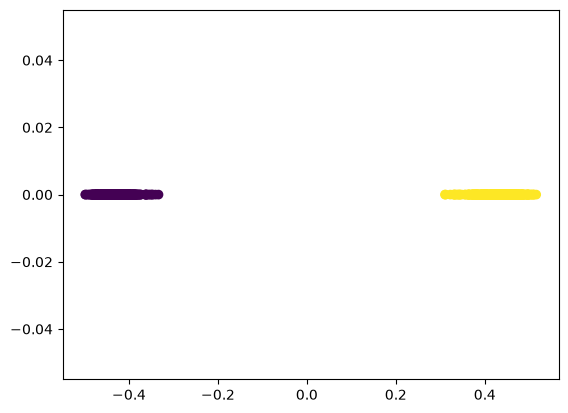

In [101]:
plt.scatter(x_train_transform, np.zeros((x_train_transform.shape[0],)), c=y_train)

plt.show()